# Notebook 2 Generating a Transient Population

In this notebook we generate a mixed population of supernovae (SN) and kilonovae (KN) 
within the synthetic universe constructed in Notebook 1.

We assume:

- Supernova rate ∝ Star Formation Rate (SFR)
- Kilonova rate ∝ Total Stellar Mass (M_star)
- Absolute magnitude M = -17.5 for SNe, M = -16.0 for KNe
- Survey duration T = 500,000 years

This notebook produces an intrinsic transient population and computes 
their apparent magnitudes using the distance modulus.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



## Load Synthetic Galaxy Catalogue

We import the galaxy catalogue generated in Notebook 1.

This catalogue contains:

- Distance (Mpc)
- Stellar Mass (M_star)
- Star Formation Rate (SFR)
- Galaxy properties

In [ ]:
galaxies = pd.read_csv("galaxy_catalog.csv")

print("Number of galaxies:", len(galaxies))
galaxies.head()

## Physical Event Rates

We assume simple host galaxy scaling relations.

The supernova rate in each galaxy is proportional to its star formation rate.

The kilonova rate in each galaxy is proportional to its stellar mass.

---

### Assumptions

- Core collapse supernovae trace ongoing star formation.
- Kilonovae trace stellar mass as a proxy for delayed mergers.
- Rates are constant over the survey duration.

Survey duration: 500,000 years.

---

### Normalizations

Supernova normalization: 1 × 10^-6 events per year per solar mass per year of star formation.

Kilonova normalization: 1 × 10^-18 events per year per solar mass of stellar mass.

These values reproduce realistic order-of-magnitude local event rates.

In [6]:
A_SN = 1e-6       # SN per (Msun/yr) per year
A_KN = 1e-18       # KN per Msun per year
T_survey = 500000.0     # years

## Sampling Event Counts

For each galaxy, we compute the expected number of events over the survey duration.

The expected supernova count scales with star formation rate.

The expected kilonova count scales with stellar mass.

Actual event numbers are drawn from a Poisson distribution with these expected values as the mean.

The expected totals represent the ensemble average.

The realised totals represent one Monte Carlo survey realisation.

In [7]:
lambda_SN = A_SN * galaxies["SFR"] * T_survey
lambda_KN = A_KN * galaxies["M_star"] * T_survey

N_SN = np.random.poisson(lambda_SN)
N_KN = np.random.poisson(lambda_KN)

print("Total expected SN:", lambda_SN.sum())
print("Total expected KN:", lambda_KN.sum())

print("Total realised SN:", N_SN.sum())
print("Total realised KN:", N_KN.sum())

Total expected SN: 1507.979564289694
Total expected KN: 7.49946603880465
Total realised SN: 1592
Total realised KN: 10


## Construct Event Catalogue

We expand galaxy level event counts into an event-level table.

Each event stores:

- Event type (SN or KN)
- Host galaxy distance

This produces the intrinsic transient population.

In [8]:
events = []

for i in range(len(galaxies)):
    d = galaxies["distance"].iloc[i]
    q = galaxies["is_quiescent"].iloc[i]

    
    # Add SN events
    for _ in range(N_SN[i]):
        events.append({
            "type": "SN",
            "distance": d,
            "gal": q
        })
    
    # Add KN events
    for _ in range(N_KN[i]):
        events.append({
            "type": "KN",
            "distance": d,
            "gal": q
        })

events = pd.DataFrame(events)

print("Total SN:", (events["type"] == "SN").sum())
print("Total KN:", (events["type"] == "KN").sum())
print("Total events:", len(events))

Total SN: 1592
Total KN: 10
Total events: 1602


## Convert to Apparent Magnitude

We assign type-specific absolute magnitudes based on typical peak values:

- SNe: M = -17.5 (typical Type IIb peak)
- KNe: M = -16.0 (typical kilonova peak)

The distance modulus is:

μ = 5 log10(d_Mpc × 10^6) − 5

The apparent magnitude is:

m = M + μ


In [ ]:
M_abs_SN = -17.5   # typical Type IIb peak
M_abs_KN = -16.0   # typical kilonova peak

events["M_abs"] = np.where(events["type"] == "SN", M_abs_SN, M_abs_KN)
events["mu"] = 5 * np.log10(events["distance"] * 1e6) - 5
events["m"] = events["M_abs"] + events["mu"]

events.head()

### Brightness Range of Injected Events

This cell computes the apparent magnitude range of the simulated transient population.

- The minimum value of `m` corresponds to the brightest detected event.
- The maximum value of `m` corresponds to the faintest detected event.

This provides a quick validation that the injected supernovae and kilonovae span a physically reasonable magnitude range within the survey limits.


In [10]:
print("Brightest event:", events["m"].min())
print("Faintest event:", events["m"].max())

Brightest event: 17.204333424962954
Faintest event: 22.493326367635355


### Apparent Magnitude as a Function of Distance

This cell compares the simulated events to the theoretical distance–magnitude relation.

- A smooth distance grid is created between the minimum and maximum event distances.
- Two model curves are plotted: M = -17.5 for SNe and M = -16.0 for KNe.
- The simulated event magnitudes are plotted as scatter points coloured by type.
- The y-axis is inverted because lower magnitudes correspond to brighter objects.

This verifies that the injected events follow the expected luminosity–distance scaling.

In [ ]:
d = np.linspace(events["distance"].min(),
                events["distance"].max(), 500)

m_model_SN = M_abs_SN + 5 * np.log10(d * 1e6) - 5
m_model_KN = M_abs_KN + 5 * np.log10(d * 1e6) - 5

plt.figure()
plt.scatter(events[events["type"] == "SN"]["distance"],
            events[events["type"] == "SN"]["m"],
            s=5, alpha=0.5, label="SN")
plt.scatter(events[events["type"] == "KN"]["distance"],
            events[events["type"] == "KN"]["m"],
            s=20, label="KN")
plt.plot(d, m_model_SN, label="M = -17.5 (SN)")
plt.plot(d, m_model_KN, label="M = -16.0 (KN)")

plt.xlabel("Distance (Mpc)")
plt.ylabel("Apparent Magnitude")
plt.legend(frameon=False)
plt.gca().invert_yaxis()
plt.show()

### Apparent Magnitude Distribution: Supernovae vs Kilonovae

This cell compares the apparent magnitude distributions of Supernovae (SN) and Kilonovae (KN).

- The events are separated by type (`SN` and `KN`).
- Histograms of their apparent magnitudes (`m`) are plotted.
- A logarithmic y-axis is used to clearly show differences in event counts.
- This highlights the relative abundance of SN compared to the much rarer KN population.

The plot allows a direct visual comparison of brightness distributions and population imbalance between the two transient types.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(events[events['type'] == 'SN']['m'], bins=20, label='SN', alpha=0.7)
ax.hist(events[events['type'] == 'KN']['m'], bins=10, label='KN', alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel("Apparent Magnitude")
ax.set_ylabel("Number of Events")
ax.set_title("Apparent Magnitude Distribution: SN vs KN")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Inspecting Kilonova Events in the Synthetic Sample

This cell filters the event catalogue to show only Kilonova (KN) events.


In [13]:
events[events['type']=='KN']


,type,distance,gal,mu,m
65,KN,379.525252,False,37.896203,21.896203
185,KN,402.933783,False,38.026168,22.026168
233,KN,258.259142,False,37.060279,21.060279
264,KN,399.284747,True,38.006414,22.006414
367,KN,420.822881,False,38.120497,22.120497
669,KN,386.676100,False,37.936737,21.936737
903,KN,361.873435,False,37.792784,21.792784
1029,KN,386.202018,False,37.934073,21.934073
1202,KN,482.181682,False,38.416054,22.416054
1460,KN,385.161887,False,37.928217,21.928217


## SN 1993J r-band Light Curve

This cell plots the observed r-band light curve of the Type IIb supernova SN 1993J.

- The x-axis shows time in days since explosion.
- The y-axis shows apparent R-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point is a real observational measurement.

This allows direct visual comparison with AT2017gfo.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load SN 1993J dataset
df_r = pd.read_csv("sn1993j_full_dataset.csv")

plt.figure(figsize=(6, 4))
plt.scatter(df_r["t_days"], df_r["R_app"], s=25)

plt.gca().invert_yaxis()

plt.xlabel("Days since explosion")
plt.ylabel("r-band magnitude")
plt.title("SN 1993J r-band Light Curve (Data)")

plt.tight_layout()
plt.show()

### Loading the AT2017gfo r-band Kilonova Data

This cell loads the real photometric data for the kilonova AT2017gfo.

- The file contains multi-band observations compiled from the literature.
- Each row corresponds to a measurement at a given time since merger (`Phase`).
- The `mag` column contains the observed apparent magnitude.
- The `Band` column specifies the filter (we will later isolate r-band only).

This dataset provides a fully data-driven kilonova light curve for direct comparison with the Type IIb supernova.


In [ ]:
df_kn = pd.read_csv("at2017gfo_rband.csv")
df_kn.head()

### Selecting Only r-band Kilonova Data

This cell filters the full AT2017gfo dataset to keep only r-band measurements.

- The original table contains multiple photometric bands.
- We restrict to rows where `Band == "r"`.
- A copy of the filtered dataframe is created to avoid modifying the original data.

This ensures we are comparing SN 2011dh and AT2017gfo in the same photometric band.


In [16]:
df_kn_r = df_kn[df_kn["Band"] == "r"].copy()
df_kn_r.tail()


,MJD,Phase,Inst,Tel,Band,l_mag,mag,e_mag,Delta,Ref,Use,Avg,Rt,Out,Exc
627,57993.400,10.871,Skymapper,Skymapper,r,>,19.39,NaN,0.0,2017arXiv171005846A,*,NaN,NaN,NaN,NaN
669,57994.969,12.440,VIMOS,VLT,r,NaN,23.12,0.31,0.0,2017ApJ...848L..27T,*,NaN,NaN,NaN,NaN
677,57995.389,12.860,Skymapper,Skymapper,r,>,19.32,NaN,0.0,2017arXiv171005846A,*,NaN,NaN,NaN,NaN
713,57998.999,16.470,GMOS,Gemini-S,r,>,21.18,NaN,0.0,2017arXiv171005436K,*,NaN,NaN,NaN,NaN
717,58000.009,17.480,GMOS,Gemini-S,r,>,21.98,NaN,0.0,2017arXiv171005436K,*,NaN,NaN,NaN,NaN


### AT2017gfo r-band Light Curve


We apply a physical sanity filter:

- Use r-band only  
- Respect published upper limits  
- After 8 days, any point brighter than 20.5 mag is treated as an upper limit  

This prevents artificial late-time rebrightening.


In [ ]:
print("Total points (all bands):", len(df_kn))

# Keep only r-band
df_kn = df_kn[df_kn["Band"] == "r"].copy()

print("r-band points:", len(df_kn))

## Apparent r-band Light Curves

This cell plots the observed r-band light curves of SN 1993J and AT2017gfo.

- The x-axis shows time in days since explosion (SN 1993J) or merger (AT2017gfo).
- The y-axis shows apparent r-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point represents a real observational measurement.

This allows direct visual comparison between a Type IIb supernova and a kilonova in the same photometric band.

In [ ]:
import matplotlib.pyplot as plt

# --- SN 1993J (loaded above) ---
phase_sn = df_r["t_days"]
r_sn = df_r["R_app"]

# --- AT2017gfo ---
df_kn_r = df_kn[df_kn["Band"] == "r"].copy()

# Apply late-time rule
mask_kn = ((df_kn_r["Phase"] > 8) & (df_kn_r["mag"] < 20.5)) | (df_kn_r["Phase"] > 16)

kn_det = df_kn_r[~mask_kn]
kn_lim = df_kn_r[mask_kn]

phase_kn_det = kn_det["Phase"]
r_kn_det = kn_det["mag"]

phase_kn_lim = kn_lim["Phase"]
r_kn_lim = kn_lim["mag"]

plt.figure(figsize=(8, 5))

plt.scatter(phase_sn, r_sn, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, r_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, r_kn_lim, marker="v", s=40, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Apparent r-band magnitude")
plt.title("Apparent r-band Light Curves")

plt.gca().invert_yaxis()
plt.xlim(0, 45)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Absolute r-band Light Curves

This cell converts both light curves to absolute magnitude.

- The distance modulus is computed using:
  μ = 5 log10(d_Mpc × 10^6) − 5
- SN 1993J is assumed to be at 3.6 Mpc.
- AT2017gfo is assumed to be at 40 Mpc.
- Absolute magnitude is computed as:
  M = m − μ

This allows direct physical comparison of intrinsic brightness.

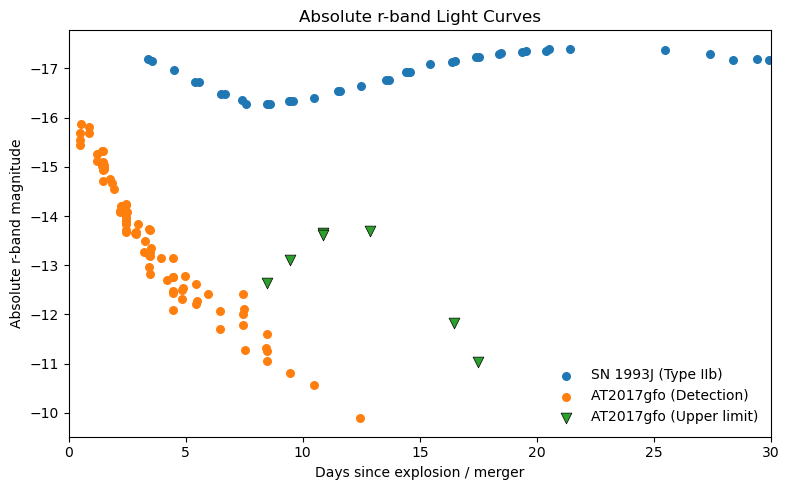

In [20]:
import numpy as np
# --- Clean AT2017gfo r-band first ---
df_kn_r = df_kn[df_kn["Band"] == "r"].copy()

mask_kn = ((df_kn_r["Phase"] > 8) & (df_kn_r["mag"] < 20.5)) | (df_kn_r["Phase"] > 16)

kn_det = df_kn_r[~mask_kn]
kn_lim = df_kn_r[mask_kn]

phase_kn_det = kn_det["Phase"]
phase_kn_lim = kn_lim["Phase"]

r_kn_det = kn_det["mag"]
r_kn_lim = kn_lim["mag"]

# --- Distance Moduli ---
d_93 = 3.6      # Mpc
d_kn = 40.0     # Mpc

mu_93 = 5 * np.log10(d_93 * 1e6) - 5
mu_kn = 5 * np.log10(d_kn * 1e6) - 5

# --- Absolute magnitudes ---
M_93 = r_sn - mu_93
M_kn_det = r_kn_det - mu_kn
M_kn_lim = r_kn_lim - mu_kn

# --- Plot ---
plt.figure(figsize=(8,5))

plt.scatter(phase_sn, M_93, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, M_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, M_kn_lim, marker="v", s=60, edgecolor="black", linewidth=0.5, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Absolute r-band magnitude")
plt.title("Absolute r-band Light Curves")

plt.gca().invert_yaxis()
plt.xlim(0, 30)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

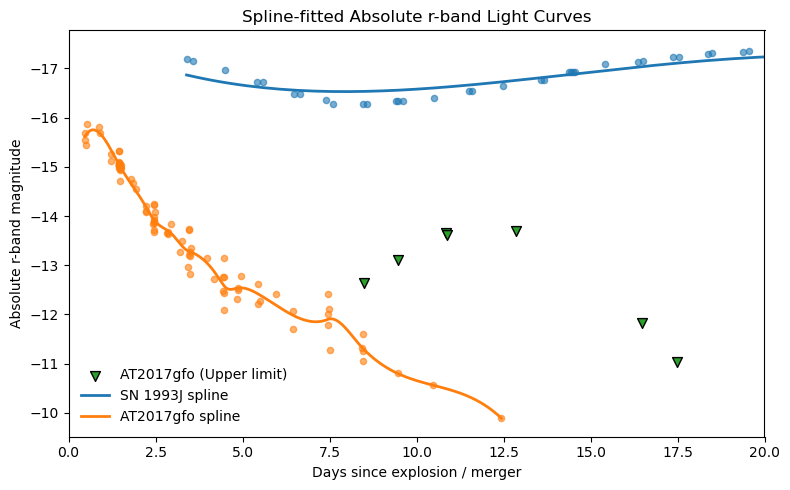

In [21]:
from scipy.interpolate import UnivariateSpline
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# SORT DATA FIRST
# -------------------------

# SN 1993J
idx_sn = np.argsort(phase_sn)
phase_sn_sorted = phase_sn.values[idx_sn]
M_sn_sorted = M_93.values[idx_sn]

# AT2017gfo (detections only)
idx_kn = np.argsort(phase_kn_det)
phase_kn_sorted = phase_kn_det.values[idx_kn]
M_kn_sorted = M_kn_det.values[idx_kn]

# -------------------------
# FIT SPLINES
# -------------------------

spline_sn = UnivariateSpline(phase_sn_sorted, M_sn_sorted, s=0.15)
spline_kn = UnivariateSpline(phase_kn_sorted, M_kn_sorted, s=3.5)

# Evaluation grids 
t_sn = np.linspace(phase_sn_sorted.min(), phase_sn_sorted.max(), 500)
t_kn = np.linspace(phase_kn_sorted.min(), phase_kn_sorted.max(), 500)

M_sn_smooth = spline_sn(t_sn)
M_kn_smooth = spline_kn(t_kn)

# -------------------------
# PLOT
# -------------------------

plt.figure(figsize=(8,5))

# Raw data
plt.scatter(phase_sn_sorted, M_sn_sorted, s=20, alpha=0.6)
plt.scatter(phase_kn_sorted, M_kn_sorted, s=20, alpha=0.6)

# Upper limits (kilonova)
plt.scatter(phase_kn_lim, M_kn_lim,
            marker="v", s=50, edgecolor="black",
            label="AT2017gfo (Upper limit)")

# Smooth curves
plt.plot(t_sn, M_sn_smooth, linewidth=2, label="SN 1993J spline")
plt.plot(t_kn, M_kn_smooth, linewidth=2, label="AT2017gfo spline")
plt.xlim(0, 20)
plt.gca().invert_yaxis()
plt.xlabel("Days since explosion / merger")
plt.ylabel("Absolute r-band magnitude")
plt.title("Spline-fitted Absolute r-band Light Curves")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()